<a href="https://colab.research.google.com/github/esemsc-db24/NewRytm/blob/main/Importing_Data_fitbit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Fitbit Data

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import fitbit

# gather_keys_oauth2.py file needs to be in the same directory.
# also needs to install cherrypy: https://pypi.org/project/CherryPy/
# pip install CherryPy
import gather_keys_oauth2 as Oauth2
import pandas as pd
import datetime


# YOU NEED TO PUT IN YOUR OWN CLIENT_ID AND CLIENT_SECRET
CLIENT_ID='23Q7KL'
CLIENT_SECRET='7f9286c713918599bb2a2e86fb73a3b5'

In [ ]:
server=Oauth2.OAuth2Server(CLIENT_ID, CLIENT_SECRET)
server.browser_authorize()
ACCESS_TOKEN=str(server.fitbit.client.session.token['access_token'])
REFRESH_TOKEN=str(server.fitbit.client.session.token['refresh_token'])
auth2_client=fitbit.Fitbit(CLIENT_ID,CLIENT_SECRET,oauth2=True,access_token=ACCESS_TOKEN,refresh_token=REFRESH_TOKEN)

[15/Feb/2025:17:46:59] ENGINE Listening for SIGTERM.
[15/Feb/2025:17:46:59] ENGINE Listening for SIGHUP.
[15/Feb/2025:17:46:59] ENGINE Listening for SIGUSR1.
[15/Feb/2025:17:46:59] ENGINE Bus STARTING
CherryPy Checker:
The Application mounted at '' has an empty config.

[15/Feb/2025:17:46:59] ENGINE Started monitor thread 'Autoreloader'.
[15/Feb/2025:17:46:59] ENGINE Serving on http://127.0.0.1:8080
[15/Feb/2025:17:46:59] ENGINE Bus STARTED
gio: https://www.fitbit.com/oauth2/authorize?response_type=code&client_id=23Q7KL&redirect_uri=http%3A%2F%2F127.0.0.1%3A8080%2F&scope=activity+nutrition+heartrate+location+nutrition+profile+settings+sleep+social+weight&state=poleZsjIzviLkmyCey5PrJVMnyEDQD: Operation not supported


127.0.0.1 - - [15/Feb/2025:17:47:05] "GET /?code=5567d70b5facd00b211d6c061a2779a12a6c7453&state=poleZsjIzviLkmyCey5PrJVMnyEDQD HTTP/1.1" 200 122 "" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/133.0.0.0 Safari/537.36"


[15/Feb/2025:17:47:06] ENGINE Bus STOPPING
[15/Feb/2025:17:47:06] ENGINE HTTP Server cherrypy._cpwsgi_server.CPWSGIServer(('127.0.0.1', 8080)) shut down
[15/Feb/2025:17:47:06] ENGINE Stopped thread 'Autoreloader'.
[15/Feb/2025:17:47:06] ENGINE Bus STOPPED
[15/Feb/2025:17:47:06] ENGINE Bus EXITING
[15/Feb/2025:17:47:06] ENGINE Bus EXITED
[15/Feb/2025:17:47:06] ENGINE Waiting for child threads to terminate...


In [ ]:
import datetime
oneDayData = auth2_client.intraday_time_series('activities/heart',
                                               base_date='2025-02-13',
                                               detail_level='1min',
                                               start_time="00:00",
                                               end_time="23:59")

if 'activities-heart-intraday' in oneDayData:
    df = pd.DataFrame(oneDayData['activities-heart-intraday']['dataset'])
    print("Intraday heart rate data successfully loaded!")
else:
    print("No intraday heart rate data available.")

Intraday heart rate data successfully loaded!


In [ ]:
help(auth2_client.intraday_time_series)

Help on method intraday_time_series in module fitbit.api:

intraday_time_series(resource, base_date='today', detail_level='1min', start_time=None, end_time=None) method of fitbit.api.Fitbit instance
    The intraday time series extends the functionality of the regular time series, but returning data at a
    more granular level for a single day, defaulting to 1 minute intervals. To access this feature, one must
    fill out the Private Support form here (see https://dev.fitbit.com/docs/help/).
    For details on the resources available and more information on how to get access, see:

    https://dev.fitbit.com/docs/activity/#get-activity-intraday-time-series



In [ ]:
oneDayData

{'activities-heart': [{'customHeartRateZones': [],
   'heartRateZones': [{'caloriesOut': 4221.36848,
     'max': 109,
     'min': 30,
     'minutes': 1401,
     'name': 'Out of Range'},
    {'caloriesOut': 222.22829999999993,
     'max': 137,
     'min': 109,
     'minutes': 31,
     'name': 'Fat Burn'},
    {'caloriesOut': 40.8457,
     'max': 171,
     'min': 137,
     'minutes': 7,
     'name': 'Cardio'},
    {'caloriesOut': 0, 'max': 220, 'min': 171, 'minutes': 0, 'name': 'Peak'}],
   'dateTime': '2025-02-13',
   'value': '70.73'}],
 'activities-heart-intraday': {'dataset': [{'time': '00:00:00', 'value': 54},
   {'time': '00:01:00', 'value': 55},
   {'time': '00:02:00', 'value': 55},
   {'time': '00:03:00', 'value': 54},
   {'time': '00:04:00', 'value': 55},
   {'time': '00:05:00', 'value': 54},
   {'time': '00:06:00', 'value': 56},
   {'time': '00:07:00', 'value': 54},
   {'time': '00:08:00', 'value': 55},
   {'time': '00:09:00', 'value': 55},
   {'time': '00:10:00', 'value': 55},

In [ ]:
df = pd.DataFrame(oneDayData['activities-heart-intraday']['dataset'])

In [ ]:
df

,time,value
0,00:00:00,54
1,00:01:00,55
2,00:02:00,55
3,00:03:00,54
4,00:04:00,55
...,...,...
1435,23:55:00,55
1436,23:56:00,55
1437,23:57:00,55
1438,23:58:00,55


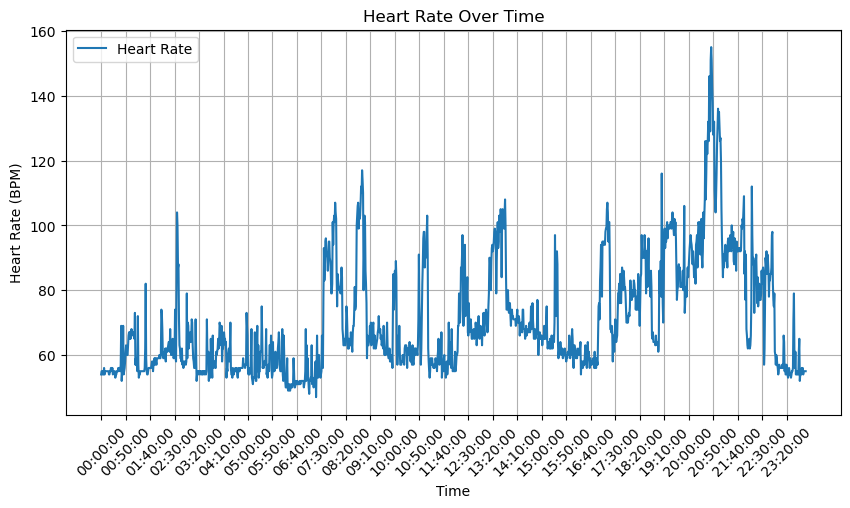

In [ ]:
# Convert 'time' to datetime (full format) but keep only the time part as a string
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.strftime("%H:%M:%S")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["value"], linestyle='-', label="Heart Rate")

# Formatting
plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over Time")
plt.xticks(df["time"][::50], rotation=45) # Rotate x-axis for better readability
plt.legend()
plt.grid(True)

# Show plot
plt.show()
